# Karatsuba Multiplication

Authors:

**Andrzej Kozdrowski**

**Tomasz Maślanka**

### 1. Introduction 

The Karatsuba algorithm is a fast multiplication algorithm for integers. It is a **divide-and-conquer algorithm** that reduces the multiplication of two n-digit numbers to three multiplications of n/2-digit numbers and, by repeating this reduction, to at most $n^{log_2{3}} \approx n^{1.58}$ single-digit multiplications.

### 2. Algorithm

The basic principle of Karatsuba's algorithm is divide-and-conquer, using a formula that allows one to compute the product of two large numbers $x$ and $y$ using three multiplications of smaller numbers, each with about half as many digits as $x$ or $y$, plus some additions and digit shifts. This basic step is, in fact, a generalization of a similar complex multiplication algorithm, where the imaginary unit $i$ is replaced by a power of the base.

Let $x$ and $y$ be represented as $n$-digit strings in some base $B$. For any positive integer $m$ less than $n$, one can write the two given numbers as
\begin{align*}
    x &= x_1 B^m + x_0, \\
    y &= y_1 B^m + y_0,
\end{align*}
where $x_0$ and $y_0$ are less than $B^m$. The product is then
\begin{align*}
    xy &= (x_1 B^m + x_0)(y_1 B^m + y_0) \\
       &= x_1 y_1 B^{2m} + (x_1 y_0 + x_0 y_1) B^m + x_0 y_0 \\
       &= z_2 B^{2m} + z_1 B^m + z_0,
\end{align*}
where
\begin{align*}
    z_2 &= x_1 y_1, \\
    z_1 &= x_1 y_0 + x_0 y_1, \\
    z_0 &= x_0 y_0.
\end{align*}



Here is a flowchart illustrating the Karatsuba algorithm:

from IPython.display import Image
Image("Karatsuba_Multiplication_flowchart.png", width=600)

Here is a Python implementation of the Karatsuba algorithm for base-10 numbers:

In [2]:
from math import ceil, floor
#math.ceil(x) Return the ceiling of x as a float, the smallest integer value greater than or equal to x.
#math.floor(x) Return the floor of x as a float, the largest integer value less than or equal to x.

def karatsuba(x,y):
    #base case
    if x < 10 and y < 10: # in other words, if x and y are single digits
        return x*y

    n = max(len(str(x)), len(str(y)))
    m = (n + 1) // 2 

    x_H = x // (10**m)
    x_L = x % (10**m)

    y_H = y // (10**m)
    y_L = y % (10**m)
    
    #recursive steps
    a = karatsuba(x_H,y_H)
    d = karatsuba(x_L,y_L)
    e = karatsuba(x_H + x_L, y_H + y_L) - a - d

    return int(a*(10**(m*2)) + e*(10**m) + d)

To compare speed of this implemementation here is Naive Multiplication Algorithm:

In [ ]:
def naive_multiplication(x, y):

    if x == 0 or y == 0:
        return 0

    str_x = str(x)
    str_y = str(y)
    
    result = [0] * (len(str_x) + len(str_y))

    str_x = str_x[::-1]
    str_y = str_y[::-1]
    
    for i in range(len(str_x)):
        for j in range(len(str_y)):
            
            product = int(str_x[i]) * int(str_y[j])
            
            result[i + j] += product
            
            result[i + j + 1] += result[i + j] // 10  
            result[i + j] %= 10 

    while len(result) > 1 and result[-1] == 0:
        result.pop()

    final_result_str = ''.join(map(str, result[::-1]))
    return int(final_result_str)

Here is speed comparison of those algorithms:

In [82]:
import time
from math import ceil, floor

def compare_algorithms(x, y):

    str_x = str(x) if len(str(x)) < 15 else str(x)[:8] + "..." + str(x)[-5:]
    str_y = str(y) if len(str(y)) < 15 else str(y)[:8] + "..." + str(y)[-5:]
    print(f"Multiplication: {str_x} * {str_y}")
    
    start_k = time.perf_counter()
    result_k = karatsuba(x, y)
    end_k = time.perf_counter()
    time_k = end_k - start_k

    start_n = time.perf_counter()
    result_n = naive_multiplication(x, y)
    end_n = time.perf_counter()
    time_n = end_n - start_n
    
    print(f"  Is the result correct? : {'✅ Yes' if result_k == result_n else '❌ No'}")
    print(f"  Time Karatsuba: {(time_k*1000):.4f} miliseconds")
    print(f"  Time Naive   : {(time_n*1000):.4f} miliseconds")
    
    if time_k < time_n:
        print(f"  => Karatsuba is {((time_n - time_k)*1000):.4f} ms faster")
    else:
        print(f"  => Naive is {((time_n - time_k)*1000):.4f} ms faster")
    print("-" * 50)


compare_algorithms(12, 12)
compare_algorithms(1234, 4321)

mucho_x = 3141592653589793238462643383279502884197169399375105820974944592
mucho_y = 2718281828459045235360287471352662497757247093699959574966967627
compare_algorithms(mucho_x, mucho_y)

Multiplication: 12 * 12
  Is the result correct? : ✅ Yes
  Time Karatsuba: 0.0375 miliseconds
  Time Naive   : 0.0746 miliseconds
  => Karatsuba is 0.0372 ms faster
--------------------------------------------------
Multiplication: 1234 * 4321
  Is the result correct? : ✅ Yes
  Time Karatsuba: 0.1547 miliseconds
  Time Naive   : 0.1188 miliseconds
  => Naive is -0.0358 ms faster
--------------------------------------------------
Multiplication: 31415926...44592 * 27182818...67627
  Is the result correct? : ✅ Yes
  Time Karatsuba: 15.3656 miliseconds
  Time Naive   : 18.1904 miliseconds
  => Karatsuba is 2.8247 ms faster
--------------------------------------------------


As we can see **Karatsuba algorithm is faster**, in particular when numbers are bigger.

Source: https://en.wikipedia.org/wiki/Karatsuba_algorithm \
Source: https://brilliant.org/wiki/karatsuba-algorithm/

### 3. RTL implementation

The behavioral implementation of Karatsuba algorithm is presented below:A structural description of the Karatsuba Multiplication is included in the **karatsuba_multiplication.srcs\sources_1** folder. 

To verify the code’s functionality, a test case was created and is located in the **karatsuba_multiplication.srcs\sim_1** folder. 

The results of the algorithm were compared with those of the naive algorithm. The test case log is presented below:

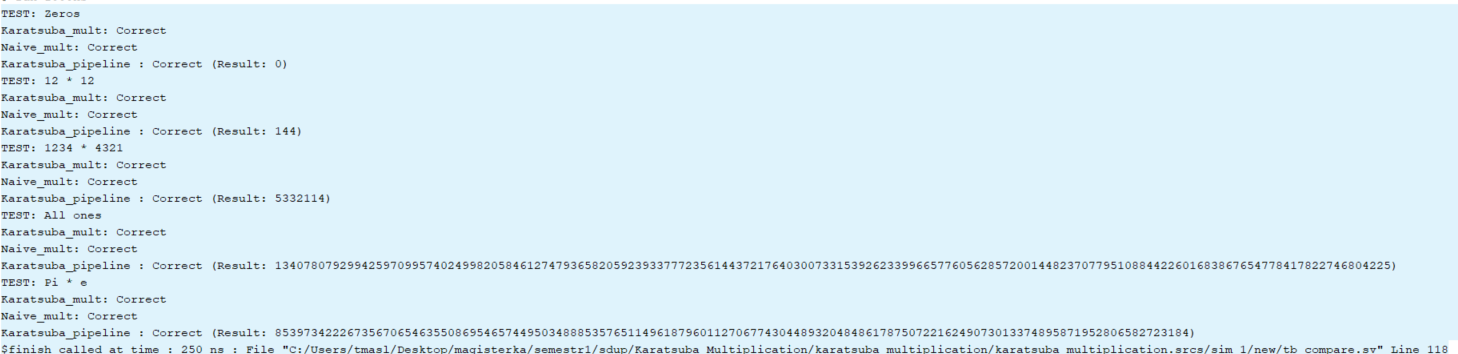

In [83]:
from IPython.display import Image
Image("log_testbech.png", width=2000)

### 4. Implementation on Kria

In the next step, the modules were equipped with AXI and connected to the processor. 

Here is a block digram of this implementation:

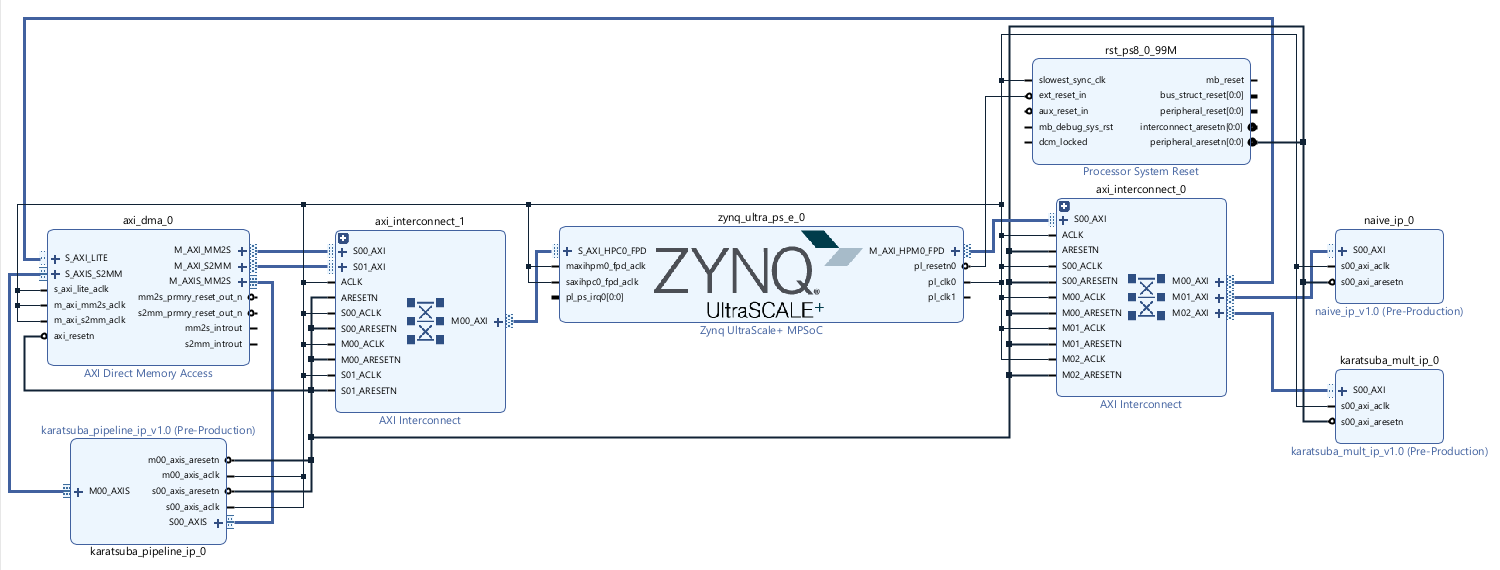

In [85]:
from IPython.display import Image
Image("design_kv260.png", width=2000)

Here is demonstration of the coprocessor's operation on data:

In [84]:
import time
import random
import numpy as np
from pynq import Overlay, allocate

OVERLAY_PATH = "kv260_karatsuba_v7.xsa"  

N_RANDOM_TESTS = 990
NAIVE_TIMEOUT = 1.0

REG_CTRL   = 0x00   
REG_X      = 0x04   
REG_Y      = 0x08   
REG_RES_LO = 0x0C   
REG_RES_HI = 0x10   
REG_DONE   = 0x14   

PIPELINE_DEPTH = 3

def section(title):
    print(f"\n{'═'*60}")
    print(f"  {title}")
    print(f"{'═'*60}")

def ok(msg):   print(f"  [PASS]  {msg}")
def fail(msg): print(f"  [FAIL]  {msg}")
def info(msg): print(f"  [INFO]  {msg}")

def naive_multiply(ip, x: int, y: int) -> tuple[int, float]:
    ip.write(REG_CTRL, 0)
    ip.write(REG_X, int(x) & 0xFFFF)
    ip.write(REG_Y, int(y) & 0xFFFF)
    ip.write(REG_CTRL, 1)
    
    t_start = time.perf_counter()
    deadline = t_start + NAIVE_TIMEOUT
    
    while True:
        if ip.read(REG_DONE) & 1:
            break
        if time.perf_counter() > deadline:
            ip.write(REG_CTRL, 0)
            raise RuntimeError(f"Timeout! x={x}, y={y}")

    elapsed = time.perf_counter() - t_start

    ip.write(REG_CTRL, 0)
    lo = ip.read(REG_RES_LO) & 0xFFFF_FFFF
    hi = ip.read(REG_RES_HI) & 0xFFFF_FFFF
    result = (hi << 32) | lo

    return result, elapsed


def run_axl_tests(ip):
    section("AXI Lite Tests")

    passed = 0
    failed = 0
    times  = []

    edge_cases = [
        (0, 0),
        (1, 0),
        (0, 1),
        (1, 1),
        (0xFFFF, 1),
        (1, 0xFFFF),
        (0xFFFF, 0xFFFF),
        (0x00FF, 0x0100),
        (0x1234, 0x5678),
        (0x8000, 0x8000),
    ]

    all_cases = edge_cases + [
        (random.randint(0, 0xFFFF), random.randint(0, 0xFFFF))
        for _ in range(N_RANDOM_TESTS)
    ]

    info(f"Total test cases: {len(all_cases)}")

    for x, y in all_cases:
        expected = x * y  
        try:
            got, t = naive_multiply(ip, x, y)
            times.append(t)
            if got == expected:
                passed += 1
            else:
                failed += 1
                fail(f"x={x:#010x} y={y:#010x} | expected={expected:#018x} | got={got:#018x}")
        except RuntimeError as e:
            failed += 1
            fail(str(e))

    if times:
        times_us = [t * 1e6 for t in times]
        info(f"Time [µs]  min={min(times_us):.1f}  max={max(times_us):.1f}  "
             f"avg={sum(times_us)/len(times_us):.1f}  "
             f"median={sorted(times_us)[len(times_us)//2]:.1f}")


    print()
    if failed == 0:
        ok(f"All {passed} tests passed ✓")
    else:
        fail(f"{passed} passed, {failed} FAILED")

    return failed == 0

def pack_sample(x: int, y: int) -> int:
    return ((y & 0xFFFF) << 16) | (x & 0xFFFF)

def run_karatsuba_tests(dma):
    section("KARATSUBA PIPELINE — AXI Stream (DMA) Tests")

    edge_cases = [
        (0, 0),
        (1, 0),
        (0, 1),
        (1, 1),
        (0xFFFF, 1),
        (1, 0xFFFF),
        (0xFFFF, 0xFFFF),
        (0x00FF, 0x0100),
        (0x1234, 0x5678),
        (0xABCD, 0xEF01),
    ]

    random_cases = [
        (random.randint(0, 0xFFFF), random.randint(0, 0xFFFF))
        for _ in range(N_RANDOM_TESTS)
    ]

    all_cases = edge_cases + random_cases
    N = len(all_cases)
    info(f"Number of samples: {N}")

    N_total = N + PIPELINE_DEPTH

    in_buf  = allocate(shape=(N_total,), dtype=np.uint32)
    out_buf = allocate(shape=(N_total,), dtype=np.uint32)

    for i, (x, y) in enumerate(all_cases):
        in_buf[i] = pack_sample(x, y)
    for i in range(PIPELINE_DEPTH):
        in_buf[N + i] = 0  

    t_start = time.perf_counter()
    dma.sendchannel.transfer(in_buf)
    dma.recvchannel.transfer(out_buf)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    elapsed = time.perf_counter() - t_start

    passed = 0
    failed = 0

    for i, (x, y) in enumerate(all_cases):
        expected = x * y                    
        got      = int(out_buf[i + PIPELINE_DEPTH])

        if got == expected:
            passed += 1
        else:
            failed += 1
            fail(f"[{i:3d}] x={x:#06x} y={y:#06x} | "
                 f"expected={expected:#010x} | got={got:#010x}")

    throughput = N / elapsed
    latency_us = elapsed / N * 1e6

    info(f"Total transfer time: {elapsed*1e3:.2f} ms for {N} samples (+{PIPELINE_DEPTH} flush)")
    info(f"Throughput: {throughput:.0f} samples/s  "
         f"({throughput*16/1e6:.2f} M-multiplications 16-bit/s)")
    info(f"Average latency: {latency_us:.2f} µs/sample")
    info(f"Pipeline depth: {PIPELINE_DEPTH} cycles (stage1 → stage2 → stage3)")

    in_buf.freebuffer()
    out_buf.freebuffer()

    print()
    if failed == 0:
        ok(f"All {passed} tests passed ✓")
    else:
        fail(f"{passed} passed, {failed} FAILED")

    return failed == 0


def run_benchmark(ip, dma, n=1000):
    section(f"BENCHMARK — {n} random multiplications")

    xs = [random.randint(0, 0xFFFF) for _ in range(n)]
    ys = [random.randint(0, 0xFFFF) for _ in range(n)]

    info("Naive IP (AXI Lite, sequential)...")
    t0 = time.perf_counter()
    for x, y in zip(xs, ys):
        naive_multiply(ip, x, y)
    t_naive = time.perf_counter() - t0
    
    info("Karatsuba IP (AXI Lite, sequential)...")
    t0 = time.perf_counter()
    for x, y in zip(xs, ys):
        naive_multiply(ip, x, y)
    t_k_mult = time.perf_counter() - t0

    info(f"Karatsuba pipeline (AXI Stream, DMA batch, flush={PIPELINE_DEPTH})...")
    in_buf  = allocate(shape=(n + PIPELINE_DEPTH,), dtype=np.uint32)
    out_buf = allocate(shape=(n + PIPELINE_DEPTH,), dtype=np.uint32)

    for i in range(PIPELINE_DEPTH):
        in_buf[i] = 0
    for i, (x, y) in enumerate(zip(xs, ys)):
        in_buf[PIPELINE_DEPTH + i] = pack_sample(x, y)

    t0 = time.perf_counter()
    dma.sendchannel.transfer(in_buf)
    dma.recvchannel.transfer(out_buf)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    t_kara = time.perf_counter() - t0

    in_buf.freebuffer()
    out_buf.freebuffer()

    print()
    print(f"  {'IP core':<28} {'Time [ms]':>10} {'Ops/s':>12} {'Speedup':>10}")
    print(f"  {'─'*28} {'─'*10} {'─'*12} {'─'*10}")
    naive_ops = n / t_naive
    kara_m_ops = n / t_k_mult
    kara_ops  = n / t_kara
    print(f"  {'naive_ip (AXI Lite)':<28} {t_naive*1e3:>10.1f} {naive_ops:>12.0f} {'1.0x':>10}")
    print(f"  {'kara_mult_ip (AXI Lite)':<28} {t_k_mult*1e3:>10.1f} {kara_m_ops:>12.0f} {kara_m_ops/naive_ops:>10.3f}x")
    print(f"  {'karatsuba_pipeline (DMA)':<28} {t_kara*1e3:>10.1f} {kara_ops:>12.0f} {kara_ops/naive_ops:>9.1f}x")
    print()
   


def main():

    info(f"Loading overlay: {OVERLAY_PATH}")
    try:
        ol = Overlay(OVERLAY_PATH)
    except Exception as e:
        print(f"\n[ERROR] Failed to load overlay: {e}")
        print("  Check the OVERLAY_PATH path at the top of the file.")
        return

    try:
        naive_ip = ol.naive_ip_0
    except AttributeError:
        print("[ERROR] 'naive_ip_0' not found in overlay.")
        print("  Check block name in HWH: ol.ip_dict.keys()")
        return
    
    try:
        kara_mult_ip = ol.karatsuba_mult_ip_0
    except AttributeError:
        print("[ERROR] 'karatsuba_mult_ip_0' not found in overlay.")
        print("  Check block name in HWH: ol.ip_dict.keys()")
        return
    
    try:
        dma = ol.axi_dma_0
    except AttributeError:
        print("[ERROR] 'axi_dma_0' not found in overlay.")
        print("  Check name: ol.ip_dict.keys()")
        return

    info("Overlay loaded successfully.")
    

    random.seed(42)

    naive_ok = run_axl_tests(naive_ip)
    kara_mult_ok = run_axl_tests(kara_mult_ip)
    kara_ok  = run_karatsuba_tests(dma)

    if naive_ok and kara_ok:
        run_benchmark(naive_ip, dma, n=1000)

    section("SUMMARY")
    print(f"  naive_ip          : {'PASS ✓' if naive_ok  else 'FAIL ✗'}")
    print(f"  kara_mult_ip      : {'PASS ✓' if kara_mult_ok  else 'FAIL ✗'}")
    print(f"  karatsuba_pipeline: {'PASS ✓' if kara_ok   else 'FAIL ✗'}")
    print()

if __name__ == "__main__":
    main()

  [INFO]  Loading overlay: kv260_karatsuba_v7.xsa
  [INFO]  Overlay loaded successfully.

════════════════════════════════════════════════════════════
  AXI Lite Tests
════════════════════════════════════════════════════════════
  [INFO]  Total test cases: 1000
  [INFO]  Time [µs]  min=10.3  max=2971.1  avg=339.5  median=237.1

  [PASS]  All 1000 tests passed ✓

════════════════════════════════════════════════════════════
  AXI Lite Tests
════════════════════════════════════════════════════════════
  [INFO]  Total test cases: 1000
  [INFO]  Time [µs]  min=9.9  max=180.8  avg=30.2  median=19.7

  [PASS]  All 1000 tests passed ✓

════════════════════════════════════════════════════════════
  KARATSUBA PIPELINE — AXI Stream (DMA) Tests
════════════════════════════════════════════════════════════
  [INFO]  Number of samples: 1000
  [INFO]  Total transfer time: 0.43 ms for 1000 samples (+3 flush)
  [INFO]  Throughput: 2339652 samples/s  (37.43 M-multiplications 16-bit/s)
  [INFO]  Average l